# 16 — Qué información utiliza el candidato semanal elegido tras comparar el aporte del clima

Se reconstruye el ajuste de agosto de la alternativa elegida en 19 con validación anterior a 2026. Se verifica su predicción antes de explicar. La importancia por permutación mide cuánto empeora el WAPE al alterar cada variable o bloque en los casos principales de agosto. No es SHAP, no representa tallos aportados y no demuestra causalidad.

Se incluyen referencia (media4 o teoría), corrector y recorte a cero. Cinco permutaciones con semilla fija, sin reentrenar. Los bloques se alteran conjuntamente; las barras de error son dispersión entre permutaciones, no intervalos de confianza. Las correlaciones y combinaciones poco habituales pueden afectar el ranking. El análisis describe un mes, no todos los años.

Ejecutar después de 19. Las funciones y la preparación están contenidas aquí; los archivos de datos son dependencias explícitas.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits

ROOT = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"Datos_analiticos_proyecto").is_dir())
SALIDA = ROOT/"Datos_analiticos_proyecto"

KEY=['finca','producto','color','variedad']
DESTINO=SALIDA/'modelo_con_proyecciones_teoricas'
integrados=pd.read_parquet(DESTINO/'base_analitica_proyecciones.parquet')
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
categoricas=['producto','color','variedad']
temporales=['horizonte','semana_seno','semana_coseno']
memoria=['produccion_lag1','produccion_lag2','produccion_lag3','media_4','media_8','desv_4','tendencia_4_8','cambio_reciente','produccion_52']
climaticas=[v+s for v in ['temperatura_semana','humedad_semana','radiacion_semana'] for s in ['_lag1','_media4']]
agronomicas=[]
X_columnas=categoricas+temporales+memoria+climaticas
X_teoria=X_columnas+['teoria_modelo','antiguedad_curva','desviacion_reciente_teoria']
X_historia=X_teoria+['teoria_previa_1','teoria_previa_2','revision_teoria']
assert 'y' not in X_historia
assert not integrados.duplicated(KEY+['origen','horizonte']).any()

from IPython.display import display
AUD=ROOT/'Notebooks/Proyecciones Teoricas Propias/resultados_todos_los_anios/auditoria_calidad'


In [2]:
CORTES = [pd.Timestamp("2025-07-07"),pd.Timestamp("2026-01-05"),pd.Timestamp("2026-05-04")]
SEMANAS_EVALUACION = 8

def crear_modelo(nombre,columnas):
    numericas = [c for c in columnas if c not in categoricas]
    numerico = make_pipeline(SimpleImputer(strategy="median",add_indicator=True,keep_empty_features=True),
                             StandardScaler()) if nombre.startswith("Ridge") else SimpleImputer(
                                 strategy="median",add_indicator=True,keep_empty_features=True)
    preparar = ColumnTransformer([
        ("categorias",OneHotEncoder(handle_unknown="ignore",sparse_output=False,dtype=np.float32),categoricas),
        ("numericas",numerico,numericas)])
    estimador = Ridge(alpha=100.0) if nombre.startswith("Ridge") else HistGradientBoostingRegressor(
        learning_rate=.08,max_iter=80,max_leaf_nodes=15,min_samples_leaf=40,
        l2_regularization=1.0,early_stopping=False,random_state=42)
    return make_pipeline(preparar,estimador)
print("Para el sesgo vigente de 19: positivo significa sobreestimación (predicción menos real).")
print("±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.")


Para el sesgo vigente de 19: positivo significa sobreestimación (predicción menos real).
±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.


In [3]:
llave=KEY+['origen','semana_objetivo','horizonte']
actual=pd.read_parquet(DESTINO/'comparacion_features_diarias_2026.parquet')
f=pd.read_parquet(SALIDA/'modelo_diario/features_diarias.parquet')
diarias=[c for c in f if c not in KEY+['fecha']]
integrados=integrados.merge(f.rename(columns={'fecha':'origen'}),on=KEY+['origen'],how='left',validate='many_to_one')
base=pd.read_parquet(DESTINO/'produccion_clima_semanal.parquet')
def memoria_larga(base):
    calendario=pd.DataFrame({'origen':pd.date_range(base.semana_inicio.min(),base.semana_inicio.max()+pd.Timedelta(weeks=1),freq='W-MON')})
    z=base[KEY].drop_duplicates().merge(calendario,how='cross').merge(base[KEY+['semana_inicio','tallos_reales']].rename(columns={'semana_inicio':'origen'}),on=KEY+['origen'],how='left',validate='one_to_one').sort_values(KEY+['origen'])
    g=z.groupby(KEY).tallos_reales
    z['media_12']=g.transform(lambda s:s.shift(1).rolling(12,min_periods=4).mean())
    for v in [8,12]:z[f'desv_{v}']=g.transform(lambda s:s.shift(1).rolling(v,min_periods=4).std())
    for v in [4,8,12]:z[f'reportes_{v}']=g.transform(lambda s:s.shift(1).rolling(v,min_periods=1).count())
    return z.drop(columns='tallos_reales')
extra=memoria_larga(base)
extra_cols=[c for c in extra if c not in KEY+['origen']]
integrados=integrados.merge(extra,on=KEY+['origen'],how='left',validate='many_to_one')
integrados['tendencia_4_12']=integrados.media_4-integrados.media_12
extra_cols+=['tendencia_4_12']
alterada=base.copy(); corte_prueba=pd.Timestamp('2025-01-06')
alterada.loc[alterada.semana_inicio.ge(corte_prueba),'tallos_reales']+=1000000
prueba=memoria_larga(alterada)
pd.testing.assert_frame_equal(extra.loc[extra.origen.le(corte_prueba)].reset_index(drop=True),prueba.loc[prueba.origen.le(corte_prueba)].reset_index(drop=True))
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
datos['grupo_h']=np.where(datos.horizonte.le(2),'H1_H2','H3_H5')
elegibles=datos.merge(actual[llave],on=llave,how='inner',validate='one_to_one')
assert len(elegibles)==len(actual)
Xbase=X_columnas+diarias
Xteoria=X_teoria+diarias
historia=['teoria_previa_1','teoria_previa_2','revision_teoria']
display(datos[extra_cols].isna().mean().mul(100).to_frame('faltantes_pct'))
print('Prueba temporal superada: alterar producción futura no cambia las variables disponibles al origen.')

# Incorporar la alternativa fijada antes de 2026 y reproducir su preparación exacta.
OUT=SALIDA/'revision_clima_finca'
config=pd.read_parquet(OUT/'comparacion_clima_curvas_2026.parquet')
assert config.modelo_seleccionado.nunique()==1
etapa=config.modelo_seleccionado.iloc[0]
fclima=pd.read_parquet(OUT/'features_clima_ampliado.parquet')
extra_clima=[c for c in fclima if c not in ['finca','origen']]
datos=datos.merge(fclima,on=['finca','origen'],how='left',validate='many_to_one')
if etapa=='Curva_Gaitana_clima':
    local=pd.read_parquet(OUT/'proyecciones_gaitana_inferida.parquet').rename(columns={'semana_proyeccion':'semana_objetivo'})
    datos=datos.merge(local,on=['plano','semana_objetivo']+['union_'+c for c in KEY],how='left',validate='many_to_one')
    datos['curva_completa']=datos.teoria_local.notna()&datos.sin_cobertura_local.eq(0)
    datos['teoria_modelo']=datos.teoria_local.where(datos.curva_completa)
    datos['desviacion_reciente_teoria']=datos.media_4-datos.teoria_modelo
elegibles=datos.merge(actual[llave],on=llave,how='inner',validate='one_to_one')
clima_basico=climaticas+[c for c in diarias if any(v in c for v in ['temperatura','humedad','radiacion'])]
print('Modelo explicado, elegido en validación pre2026:',etapa)


,faltantes_pct
media_12,0.0
desv_8,0.0
desv_12,0.0
reportes_4,0.0
reportes_8,0.0
reportes_12,0.0
tendencia_4_12,0.0


Prueba temporal superada: alterar producción futura no cambia las variables disponibles al origen.


Modelo explicado, elegido en validación pre2026: Sin_clima


## 1. Reproducir el modelo y separar las dos rutas

Hay dos grupos de horizonte (H1–H2 y H3–H5). En cada uno, el respaldo aprende el ajuste sobre media4 usando todos sus casos de entrenamiento; la ruta teórica aprende el ajuste sobre teoría con los casos completos. La importancia de cada ruta se calcula sólo en los casos donde efectivamente se usa.

Los casos con poco soporte se muestran con su tamaño: no se extrapolan sus rankings a toda la finca. Mantener producto/color/variedad juntos en el bloque de identidad evita romper esa identidad al evaluar bloques.

In [4]:
guardadas=config.rename(columns={'Seleccion_pre2026':'Memoria_larga'})
mes_explicado='2026-08'
te=elegibles.loc[elegibles.origen.dt.to_period('M').astype(str).eq(mes_explicado)].copy()
corte=te.origen.min()
tr=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte)]
assert tr.semana_objetivo.max()+pd.Timedelta(days=7)<=corte
FIG=ROOT/'Trabajo escrito/Figuras_resultados'; FIG.mkdir(exist_ok=True)
bloques={'Identidad comercial':categoricas,'Horizonte y calendario':temporales,'Producción semanal reciente':memoria,'Memoria larga':extra_cols,'Clima semanal':climaticas,'Corte diario reciente':[c for c in diarias if c.startswith('corte_') or c=='dias_desde_corte'],'Clima diario reciente':[c for c in diarias if c not in ['dias_desde_corte'] and not c.startswith('corte_')],'Teoría y desvío':['teoria_modelo','antiguedad_curva','desviacion_reciente_teoria']}
bloques['Lluvia reciente']=[c for c in extra_clima if c.startswith('lluvia_')]
bloques['Clima 14 y 28 días']=[c for c in extra_clima if not c.startswith(('lluvia_','cobertura_'))]
bloques['Cobertura climática']=[c for c in extra_clima if c.startswith('cobertura_')]
filas=[]; controles=[]; predicciones=[]
for grupo,tt in te.groupby('grupo_h'):
    train=tr.loc[tr.grupo_h.eq(grupo)]
    for ruta,es_teoria in [('Respaldo',False),('Teoria_completa',True)]:
        cols=(Xteoria if es_teoria else Xbase)+extra_cols
        if etapa=='Sin_clima':cols=[c for c in cols if c not in clima_basico]
        if etapa in ['Clima_ampliado','Curva_Gaitana_clima']:cols+=extra_clima
        entrenamiento=train.loc[train.curva_completa] if es_teoria else train
        t=tt.loc[tt.curva_completa.eq(es_teoria)].copy()
        assert len(entrenamiento)>=40
        referencia='teoria_modelo' if es_teoria else 'media_4'
        modelo=crear_modelo('Boosting',cols)
        def pronosticar(x):return np.maximum(0,x[referencia].to_numpy()+modelo.predict(x[cols]))
        with threadpool_limits(limits=2):
            modelo.fit(entrenamiento[cols],entrenamiento.y-entrenamiento[referencia])
            t['reproducida']=pronosticar(t)
            comprobacion=t.merge(guardadas[llave+['Memoria_larga']],on=llave,validate='one_to_one')
            assert np.allclose(comprobacion.reproducida,comprobacion.Memoria_larga,rtol=1e-9,atol=1e-6)
            predicciones.append(t[llave+['reproducida']].assign(ruta=ruta,grupo=grupo))
            t=t.merge(guardadas[llave+['grupo_comparacion']],on=llave,validate='one_to_one')
            t=t.loc[t.grupo_comparacion.eq('principal_estricta_nominal')].copy()
            if t.empty:continue
            base_error=np.abs(t.y.to_numpy()-t.reproducida.to_numpy()).sum()/t.y.sum()
            controles.append({'grupo':grupo,'ruta':ruta,'corte':corte,'max_objetivo_train':entrenamiento.semana_objetivo.max(),'n_train':len(entrenamiento),'n_evaluacion':len(t),'WAPE_base':base_error})
            for tipo,unidades in [('Bloque',{k:[c for c in v if c in cols] for k,v in bloques.items()}),('Variable',{c:[c] for c in cols})]:
                for nombre,cc in unidades.items():
                    if not cc:continue
                    rng=np.random.default_rng(42)
                    valores=[]
                    for repeticion in range(5):
                        x=t.copy(); ix=rng.permutation(len(t))
                        x.loc[:,cc]=t.iloc[ix][cc].to_numpy()
                        error=np.abs(t.y.to_numpy()-pronosticar(x)).sum()/t.y.sum()
                        valores.append(100*(error-base_error))
                    filas.append({'grupo':grupo,'ruta':ruta,'tipo':tipo,'variable':nombre,'columnas':'; '.join(cc),'n':len(t),'aumento_WAPE_pp':np.mean(valores),'desviacion_pp':np.std(valores,ddof=1),'min_pp':min(valores),'max_pp':max(valores)})
        print(grupo,ruta,'completado',flush=True)
importancias=pd.DataFrame(filas); controles=pd.DataFrame(controles)
display(controles)
print('Predicciones de agosto reproducidas exactamente antes de permutar.')
display(importancias.loc[importancias.tipo.eq('Bloque')].sort_values(['grupo','ruta','aumento_WAPE_pp'],ascending=[True,True,False]))

H1_H2 Respaldo completado


H1_H2 Teoria_completa completado


H3_H5 Respaldo completado


H3_H5 Teoria_completa completado


,grupo,ruta,corte,max_objetivo_train,n_train,n_evaluacion,WAPE_base
0,H1_H2,Respaldo,2026-08-03,2026-07-27,57382,857,0.136115
1,H1_H2,Teoria_completa,2026-08-03,2026-07-27,16546,79,0.176541
2,H3_H5,Respaldo,2026-08-03,2026-07-27,83612,577,0.170201
3,H3_H5,Teoria_completa,2026-08-03,2026-07-27,24917,47,0.319501


Predicciones de agosto reproducidas exactamente antes de permutar.


,grupo,ruta,tipo,variable,columnas,n,aumento_WAPE_pp,desviacion_pp,min_pp,max_pp
2,H1_H2,Respaldo,Bloque,Producción semanal reciente,produccion_lag1; produccion_lag2; produccion_l...,857,82.430975,0.437029,81.868973,82.860023
4,H1_H2,Respaldo,Bloque,Corte diario reciente,corte_media_3d; corte_suma_3d; corte_dias_3d; ...,857,7.023891,0.220998,6.760300,7.259621
3,H1_H2,Respaldo,Bloque,Memoria larga,media_12; desv_8; desv_12; reportes_4; reporte...,857,0.253598,0.058972,0.194825,0.349130
1,H1_H2,Respaldo,Bloque,Horizonte y calendario,horizonte; semana_seno; semana_coseno,857,0.219321,0.215716,-0.040212,0.473530
0,H1_H2,Respaldo,Bloque,Identidad comercial,producto; color; variedad,857,0.195762,0.053208,0.116334,0.241376
51,H1_H2,Teoria_completa,Bloque,Teoría y desvío,teoria_modelo; antiguedad_curva; desviacion_re...,79,69.368963,3.733390,65.094380,73.367084
50,H1_H2,Teoria_completa,Bloque,Corte diario reciente,corte_media_3d; corte_suma_3d; corte_dias_3d; ...,79,11.988203,1.778938,9.669814,13.834882
48,H1_H2,Teoria_completa,Bloque,Producción semanal reciente,produccion_lag1; produccion_lag2; produccion_l...,79,0.107019,0.567136,-0.680466,0.855072
49,H1_H2,Teoria_completa,Bloque,Memoria larga,media_12; desv_8; desv_12; reportes_4; reporte...,79,0.088882,0.076681,-0.013934,0.163342
47,H1_H2,Teoria_completa,Bloque,Horizonte y calendario,horizonte; semana_seno; semana_coseno,79,-0.002429,0.273774,-0.319218,0.408783


## 2. Gráficos: bloques y variables, sin confundir importancia con causalidad

Una barra positiva indica que al alterar la información sube el error; una barra cerca de cero indica poca dependencia adicional en estos casos, no ausencia de relación agronómica. Una barra negativa indica que la perturbación mejoró el resultado en esta muestra. Las barras no suman 100 % y no representan tallos aportados. No comparar mecánicamente rutas con denominadores y tamaños distintos.

La teoría entra además como referencia explícita: aun si el corrector la usa poco, la predicción final puede depender mucho de ella. Las revisiones históricas no aparecen porque ninguna alternativa del experimento climático incorpora ese bloque; se evaluaron separadamente en 15.

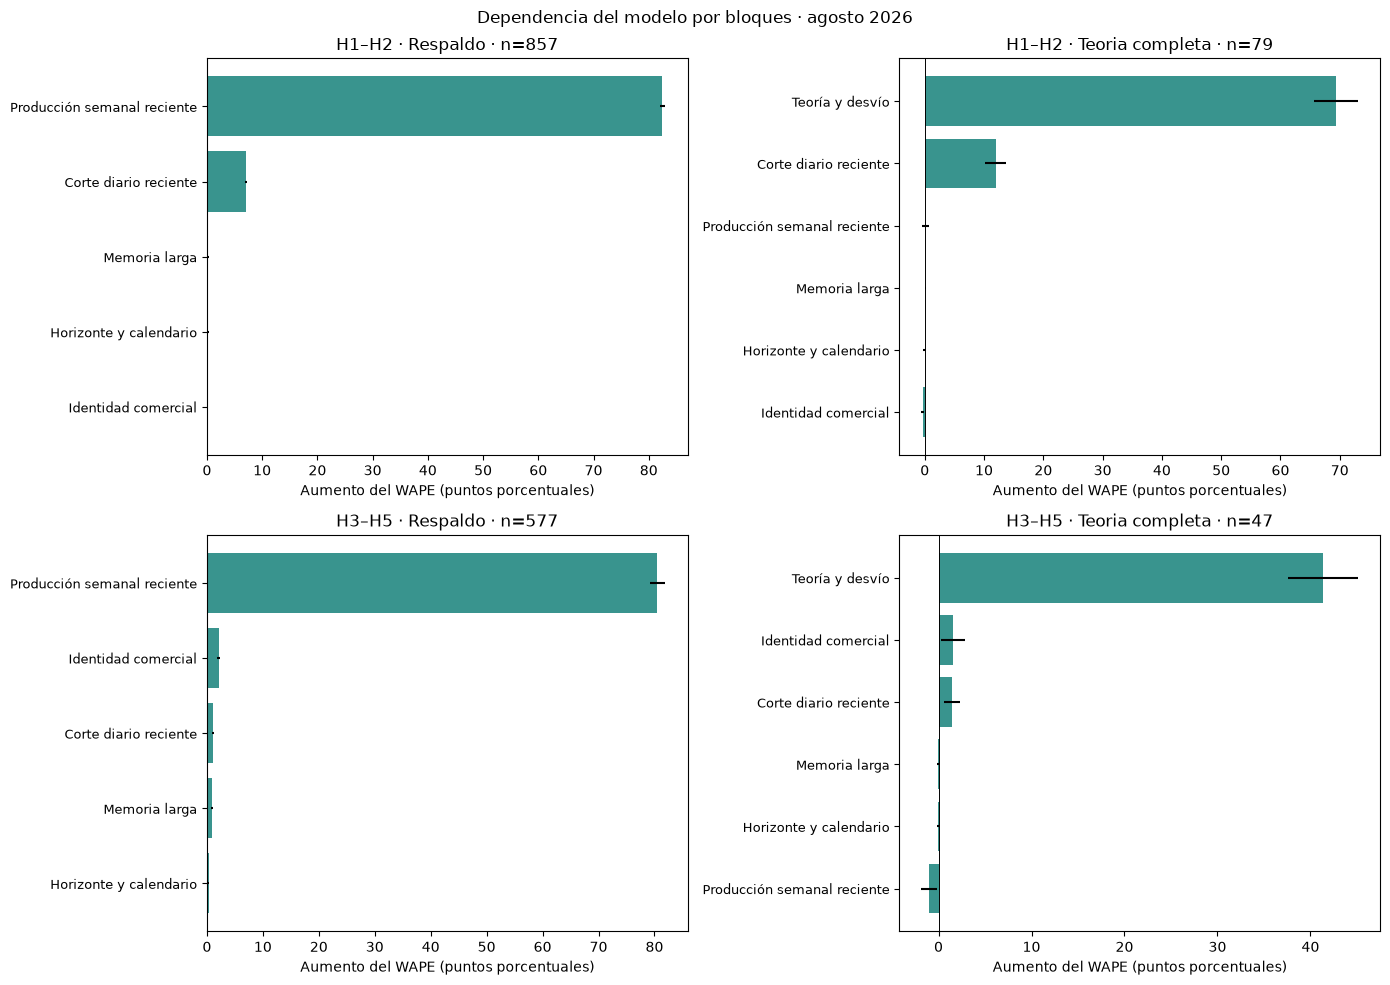

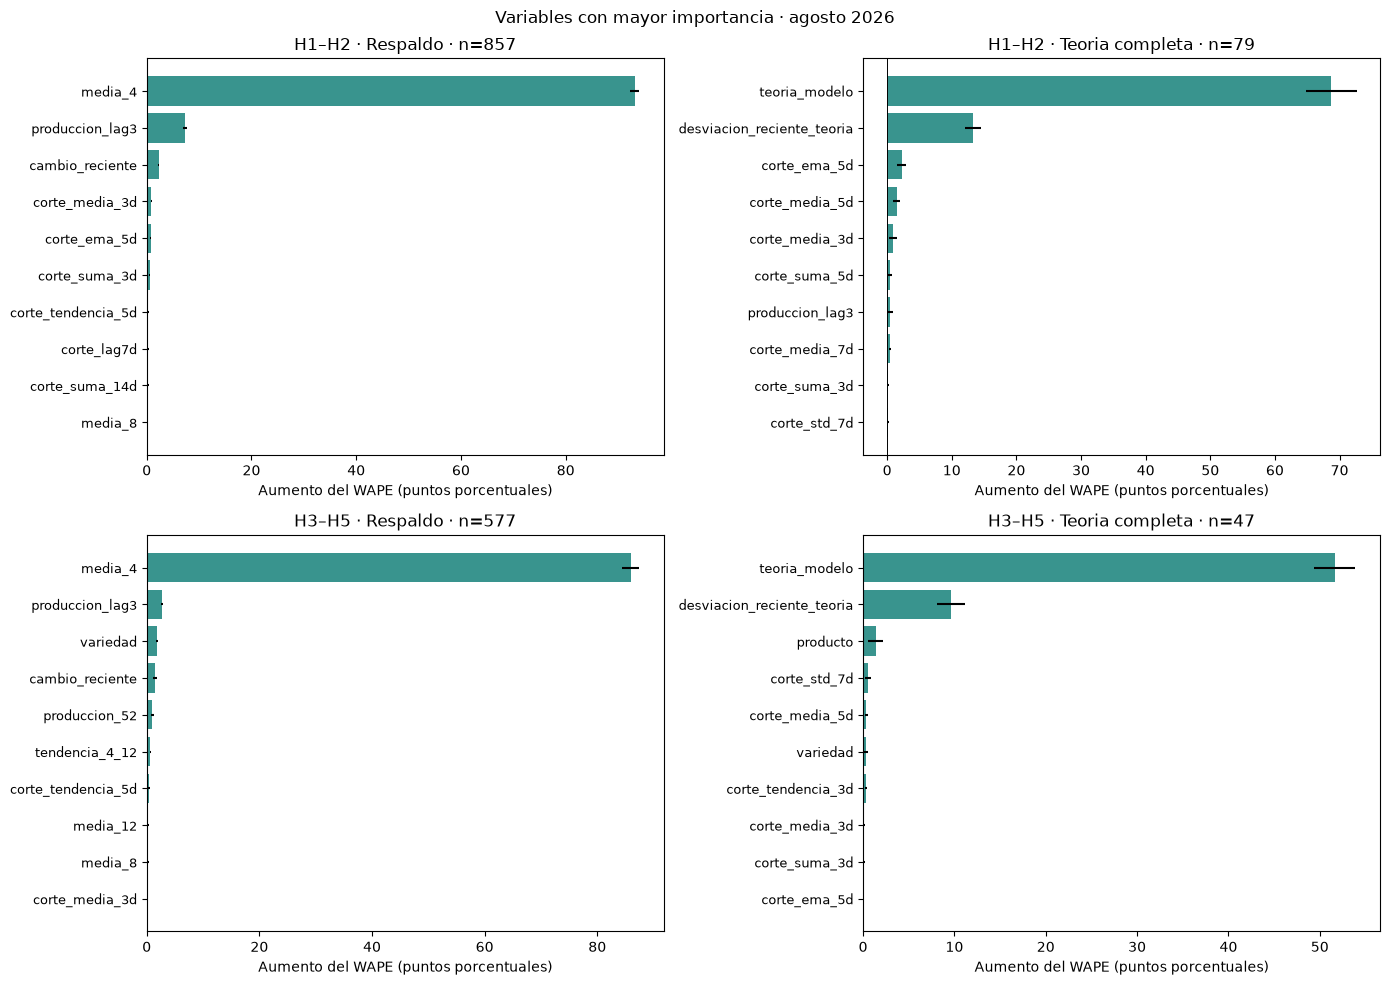

Lectura: dependencia predictiva del candidato climático local al mes evaluado, no explicación causal, no SHAP y no eliminación automática de variables.


In [5]:
for tipo,archivo,titulo in [('Bloque','importancia_bloques_semanal.png','Dependencia del modelo por bloques · agosto 2026'),('Variable','importancia_variables_semanal.png','Variables con mayor importancia · agosto 2026')]:
    fig,axs=plt.subplots(2,2,figsize=(14,10))
    for ax,(grupo,ruta) in zip(axs.flat,[(g,r) for g in ['H1_H2','H3_H5'] for r in ['Respaldo','Teoria_completa']]):
        z=importancias.loc[importancias.tipo.eq(tipo)&importancias.grupo.eq(grupo)&importancias.ruta.eq(ruta)].nlargest(10 if tipo=='Variable' else 20,'aumento_WAPE_pp').sort_values('aumento_WAPE_pp')
        ax.barh(z.variable,z.aumento_WAPE_pp,xerr=z.desviacion_pp,color='#16817a',alpha=.85)
        ax.axvline(0,color='black',lw=.7);ax.set_title(f'{grupo.replace("_","–")} · {ruta.replace("_"," ")} · n={int(z.n.iloc[0])}')
        ax.set_xlabel('Aumento del WAPE (puntos porcentuales)');ax.tick_params(axis='y',labelsize=9)
    fig.suptitle(titulo);fig.tight_layout();fig.savefig(FIG/archivo,dpi=170);plt.show()
importancias.to_parquet(DESTINO/'importancias_modelo_clima.parquet',index=False)
with pd.ExcelWriter(DESTINO/'interpretacion_modelo_semanal.xlsx') as writer:
    controles.to_excel(writer,sheet_name='Cortes_y_casos',index=False)
    importancias.loc[importancias.tipo.eq('Bloque')].to_excel(writer,sheet_name='Bloques',index=False)
    importancias.loc[importancias.tipo.eq('Variable')].to_excel(writer,sheet_name='Variables',index=False)
    pd.concat(predicciones,ignore_index=True).to_excel(writer,sheet_name='Reproduccion_agosto',index=False)
print('Lectura: dependencia predictiva del candidato climático local al mes evaluado, no explicación causal, no SHAP y no eliminación automática de variables.')